# Parcial: Curso Análisis Predictivo de Series Temporales

## Posgrado de Big Data

## Universidad ORT Uruguay

### Curso 2024 - 4/7/2024.

## Estudiante: (completar)

In [41]:
import warnings
with warnings.catch_warnings(action="ignore"):
    import astsadata as astsa
    
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats
import scipy as sp
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.api import qqplot


from statsmodels.formula.api import ols
from statsmodels.tsa.api import ARIMA
from arch import arch_model
from statsmodels.tsa.api import UnobservedComponents

import tensorflow as tf
import keras


## Ajusto tamaño de figuras
plt.rcParams['figure.figsize'] = [15,5]
plt.rcParams['axes.grid'] = True
plt.rcParams['figure.constrained_layout.use'] = True

#### Funciones útiles

In [5]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.formula.api import ols

def ccf(x, y, max_lag, ax=None, **kwargs):
    lags = np.arange(-max_lag, max_lag + 1)

    backwards = sm.tsa.ccf(x[::-1], y[::-1], adjusted=False)[max_lag::-1]
    forwards = sm.tsa.ccf(x, y, adjusted=False)[:max_lag + 1]
    ccf = np.r_[backwards[:-1], forwards]
    ylabel = "CCF"

    if ax is None:
        ax = plt.gca()
    
    ax.stem(lags, ccf, basefmt="k")
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    conf_level = 1.96 / np.sqrt(x.shape[0])
    ax.fill_between(lags,conf_level,-conf_level,alpha=0.25)
    ax.set_xlabel("LAG")
    ax.set_ylabel(ylabel)

    
    return ax

def periodogram(x,sampling_frequency=1):

    """Función que calcula el periodograma y grafica.
    
    Parameters
    ----------
        x : array_like, data.
        sampling_frequency: frecuencia de muestreo de la serie, para graficar.
    """

    n = x.size
    P = 4/n**2 * np.abs(np.fft.fft(x))**2
    P = P[0:round(n/2)]
    f = np.arange(0,round(n/2))/n * sampling_frequency
    plt.plot(f,P);
    plt.xlabel("Frequency")
    plt.ylabel("Power")


def spectrum(x,sampling_frequency=1, nfreq=10):

    """Función que calcula las componentes más relevantes del periodograma.
    
    Parameters
    ----------
        x : array_like, data.
        sampling_frequency: frecuencia de muestreo de la serie, para graficar.
    """

    n = x.size
    nfreq = np.minimum(nfreq,round(n/2)) #corto nfreq si la serie es muy corta!
    P = 4/n**2 * np.abs(np.fft.fft(x))**2
    P = P[0:round(n/2)]
    f = np.arange(0,round(n/2))/n * sampling_frequency
    index = np.argsort(P)[::-1] #ordeno P decreciente
    return pd.DataFrame({"Frecuencia" : f[index[0:nfreq]],"Potencia" : P[index[0:nfreq]]})

In [38]:
def plot_fits(fits, mses, labels):
    """Función que grafica la serie original junto con los ajustes.
    
    Parameters
    ----------
        x : array_like, data.
        fits: lista de arrays con los ajustes a graficar.
        labels: lista de strings con las etiquetas de cada ajuste.
    """
    nrows = 4
    ncols = len(fits)
    figs, axs = plt.subplots(nrows, ncols, figsize=(6 * ncols, 16), squeeze=False)
    i = 0
    for fit, label, mse in zip(fits, labels, mses):
        fit.resid.plot(ax=axs[0, i], label="Residuos")
        axs[0, i].title.set_text(f"Residuos del ajuste {label}, \n RMSE = {round(np.sqrt(mse), 4)}")
        
        plot_acf(fit.resid, ax=axs[1, i], bartlett_confint=False)
        axs[1, i].title.set_text(f"Autocorrelación (ACF) residuos \n {label}")
        
        plot_pacf(fit.resid, ax=axs[2, i])
        axs[2, i].title.set_text(f"Autocorrelación Parcial (PACF) residuos \n {label}")
        
        qqplot(fit.resid, line="s", ax=axs[3, i])
        axs[3, i].title.set_text(f"QQ Plot residuos \n {label}")
        i += 1
    plt.tight_layout()
    plt.show()

## Ejercicio 1

Se considera la serie `flu` de incidencia de muertes por gripe en Estados Unidos (en valores cada 10.000 habitantes). La serie se divide en train y test, sacando el año 1978 para test del modelo.

Se pide:

1. Discuta brevemente la serie, determinando tendencias y posibles estacionalidades. Analizar también la autocorrelación de la serie.

2. Realice el cambio de variable `log` para reducir los picos y la varianza de la serie.
   
3. Para la serie $x=\log(flu)$, realizar un ajuste lineal basado en tendencia y variables categóricas (dummy) indicando el mes. Observar si todos los meses son relevantes y justificar la elección de aquellos incluidos en el modelo final.

4. A los residuos del ajuste anterior, analice si es posible modelarlos mediante un proceso ARMA(p,q) adecuado. Justifique la elección del orden en cada caso y analice los residuos obtenidos y calcule el MSE obtenido.

5. Realizar una predicción *completa* para los años 1979 y 1980 usando el comando `fit.append` agregando los datos de test.
   
6. Combinando las prediciones del modelo lineal más la del ARMA(p,q) ajustado, y deshaciendo el cambio de variable, grafique la predicción en las variables originales.


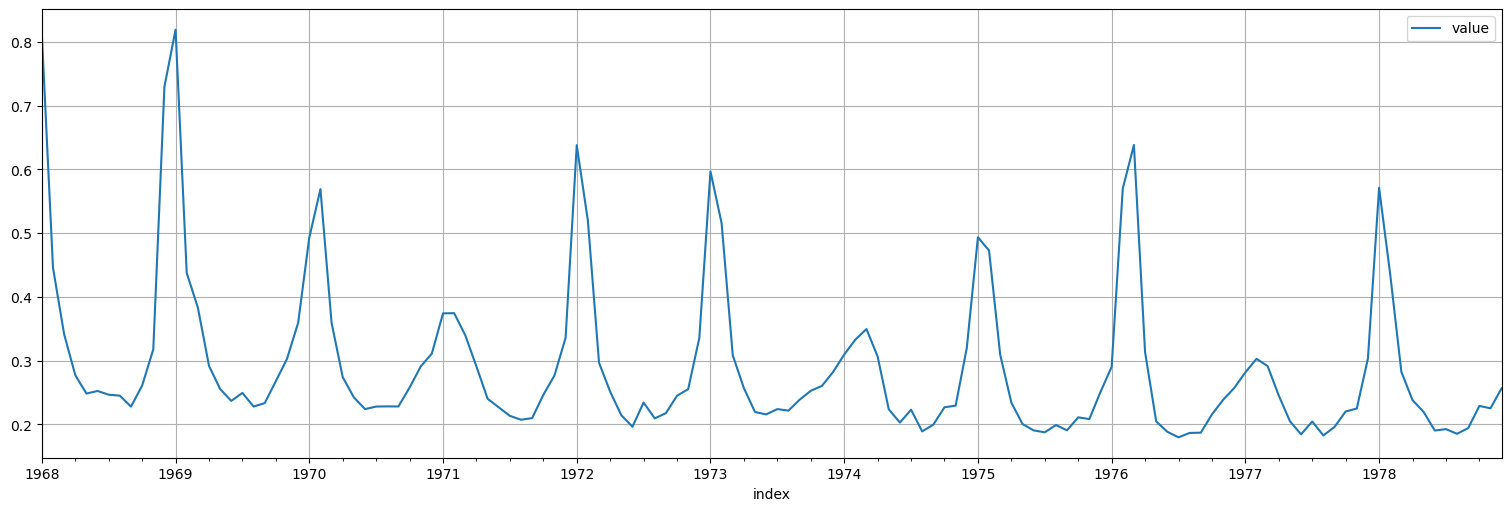

In [14]:
flu = astsa.flu
flu.plot();

In [15]:
flu.head()

,value
index,
1968-01,0.811372
1968-02,0.445829
1968-03,0.341599
1968-04,0.277424
1968-05,0.248496


La serie muestas valores mensualizados de muertes por gripe cada 10.000 hab en estados unidos.

Lo que podemos notar a simple vista es que parece mostrar un ciclo anual, haciendo su pico maximo en enero, y su pico minimo por julio (aproximadamente).

Una tendecia que puede verse tambien es que este su media parece ir bajando año a año, y los picos parecen menos pronunciados.

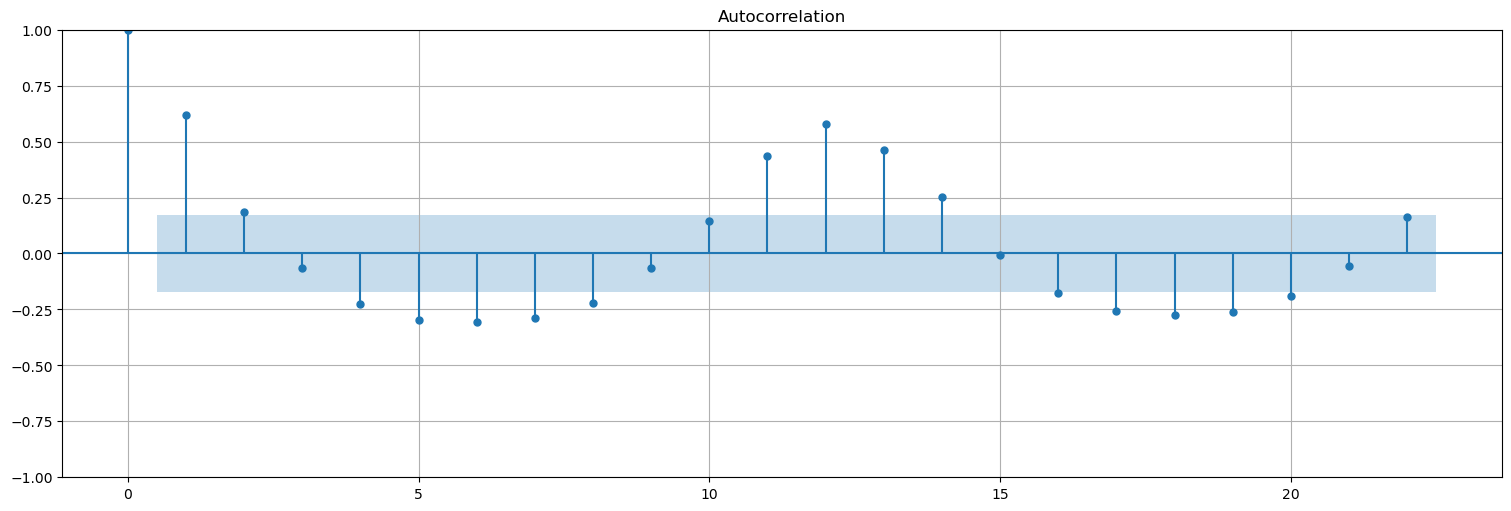

In [16]:
plot_acf(flu, bartlett_confint=False);

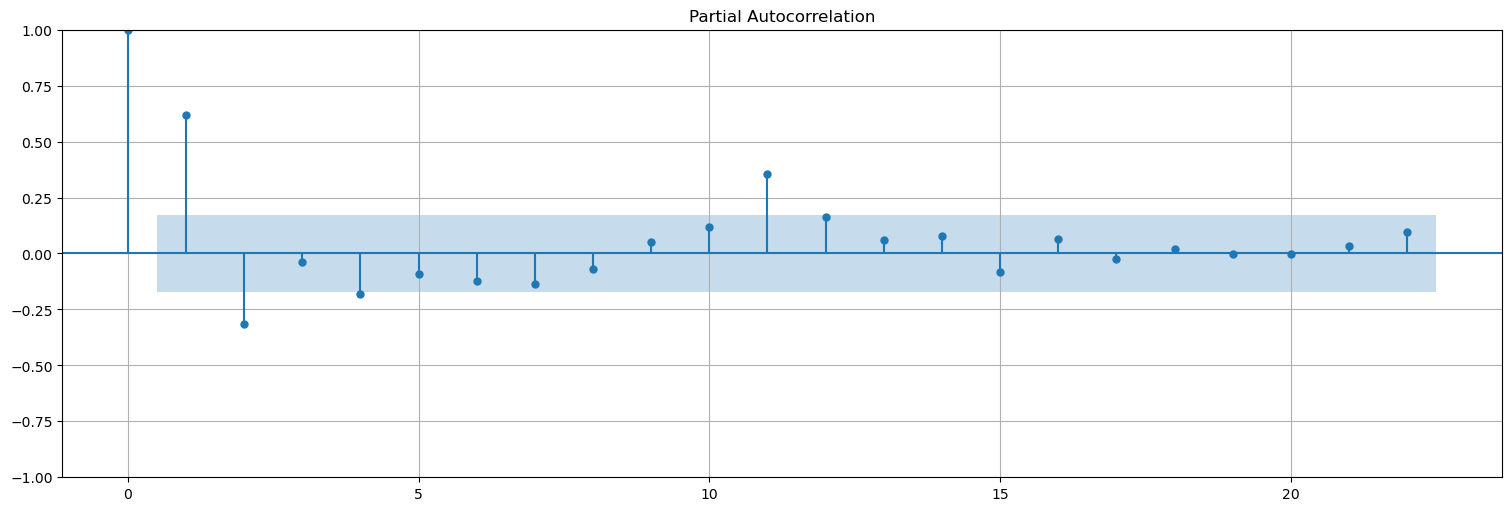

In [17]:
plot_pacf(flu);

Tanto en la auto correlacion, como en la autocorrelacion parcial, vemos un comportamiento similar, parece haber una caida paulatina a lo largo de la serie, pero notamos una correlacion fuerte año a año. 

Esto nos puede hablar de un modelo con media movil, autorregresivo y sesioncal cada 12 meses.

### Item 2

<Axes: xlabel='index'>

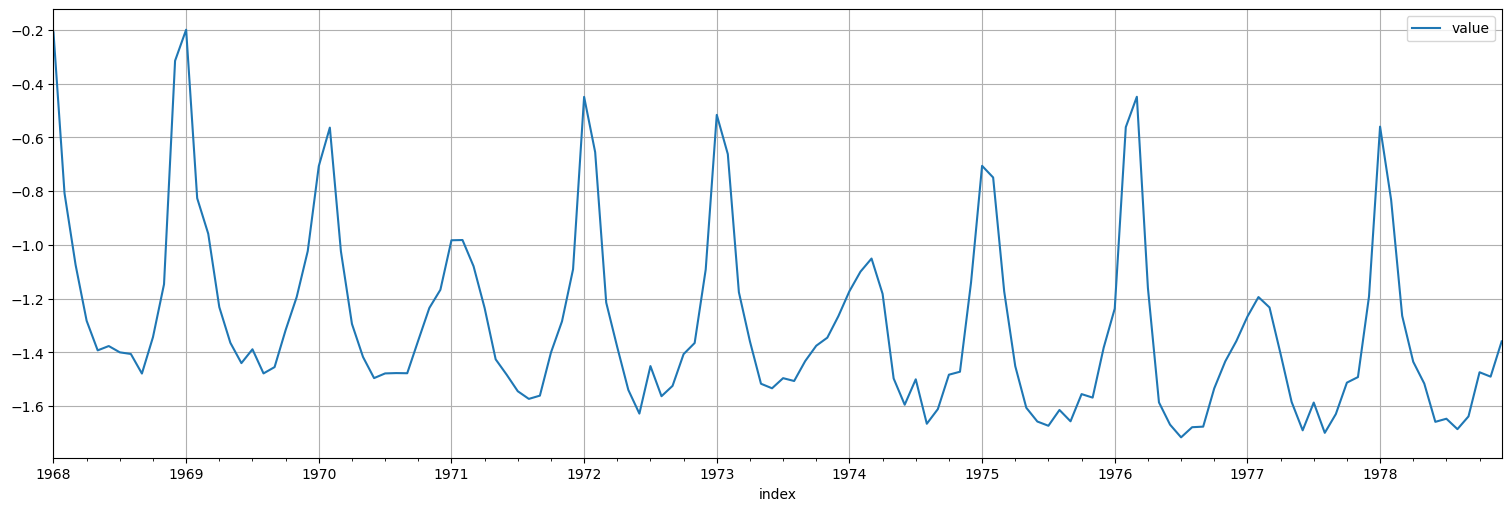

In [54]:
x = np.log(astsa.flu)
x.plot()

### Item 3

In [77]:
x_train = x[x.index.year<1978]
x_test = x[x.index.year>=1978]


In [56]:

time = pd.Series(np.arange(len(x_train)),index=x_train.index)

x_train= pd.concat([x_train["value"], time], axis=1).dropna()
x_train.columns = ["deaths", "time"]

x_train["month"] = x_train.index.month

fit1 = ols("deaths ~ C(month) + time", data=x_train).fit()
print(f"RMSE de los residuos: {np.sqrt(fit1.mse_resid)}")
fit1.summary()

RMSE de los residuos: 0.1627725315588488


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 deaths   R-squared:                       0.790
Model:                            OLS   Adj. R-squared:                  0.767
Method:                 Least Squares   F-statistic:                     33.62
Date:                Sun, 12 Jul 2026   Prob (F-statistic):           7.50e-31
Time:                        09:03:27   Log-Likelihood:                 54.455
No. Observations:                 120   AIC:                            -82.91
Df Residuals:                     107   BIC:                            -46.67
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -0.5934      0.056    -10.504      0.000      -0.705      -0.481
C(month)[T.2]     -0.0628      0.073     -0.863      0.390      -0.207       0.082
C(month)[T.3]     -0.2930      0.073     -4.025      0.000      -0.437      -0.149
C(month)[T.4]     -0.5451      0.073     -7.487      0.000      -0.689      -0.401
C(month)[T.5]     -0.7371      0.073    -10.123      0.000      -0.881      -0.593
C(month)[T.6]     -0.7981      0.073    -10.959      0.000      -0.942      -0.654
C(month)[T.7]     -0.7619      0.073    -10.461      0.000      -0.906      -0.618
C(month)[T.8]     -0.8019      0.073    -11.006      0.000      -0.946      -0.657
C(month)[T.9]     -0.7831      0.073    -10.746      0.000      -0.928      -0.639
C(month)[T.10]    -0.6585      0.073     -9.033      0.000      -0.803      -0.514
C(month)[T.11]    -0.5809      0.073     -7.966      0.000      -0.725      -0.436
C(month)[T.12]    -0.3272      0.073     -4.485      0.000      -0.472      -0.183
time              -0.0028      0.000     -6.488      0.000      -0.004      -0.002
==============================================================================
Omnibus:                       50.879   Durbin-Watson:                   1.114
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              211.771
Skew:                           1.412   Prob(JB):                     1.03e-46
Kurtosis:                       8.863   Cond. No.                         857.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Casi todos los meses parecen significativos, a excepcion del febrero, que es apenas poco significativo

#### Item 3

/var/folders/zc/xfn7bz2d1wj_vv2lvqvmndcr0000gp/T/ipykernel_12850/3390279225.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


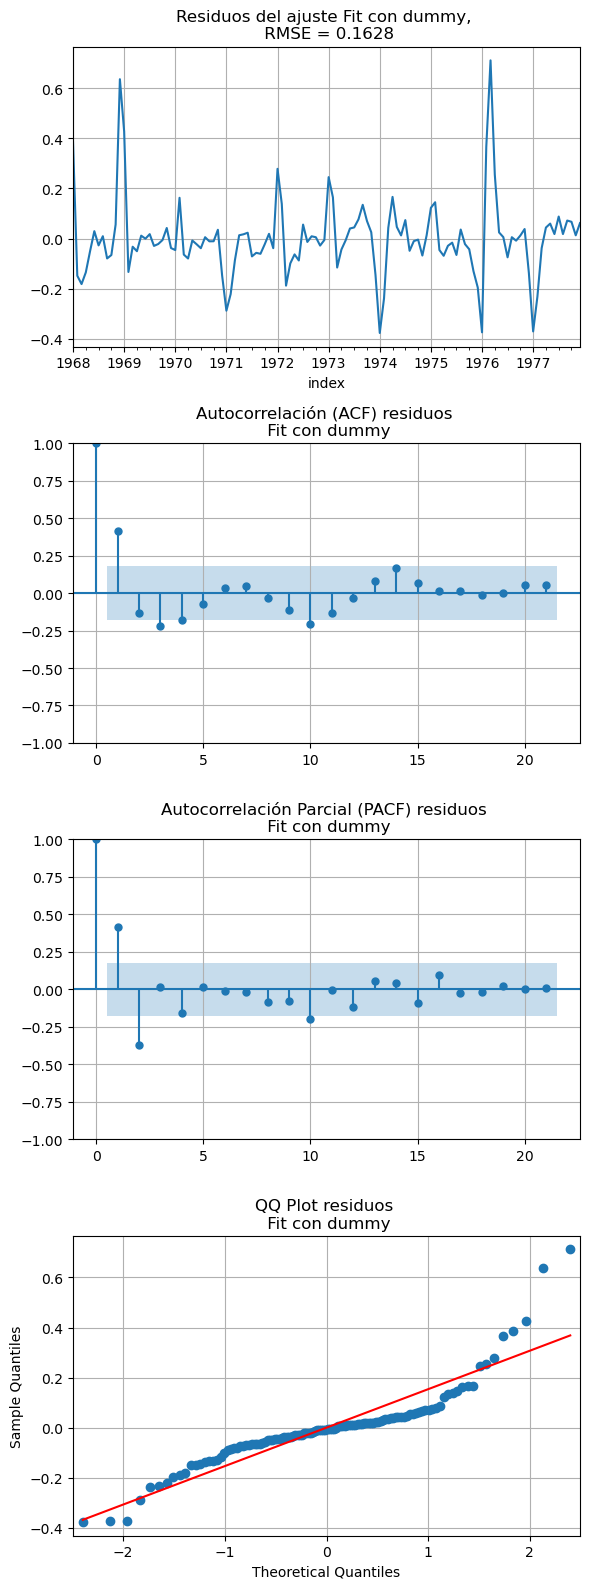

In [59]:
residuos1= fit1.resid
mse1=fit1.mse_resid
plot_fits([fit1],[mse1],["Fit con dummy"] )

los residuos aun no responden a una funcion gausseana, con lo que podemos segui iterando.

Se ve que en el PACF hay 2 componente que mantiene correlacion, con lo que podemos pensar en un AR(2). Por otra parte en el ACF vemos 1 componentes que mantienen esta corralacion, porque lo podemos pensar en un modelo de media movil de orden 1.

Con ambas concluciones podemos hablar de un ARMA(1,2).

In [60]:
fit2 = ARIMA(residuos1,order=(1,0,2), trend="n").fit()
mse2=np.sqrt(fit2.mse)
print(f"MSE del modelo ARIMA(1,0,2): {mse2}")
fit2.summary()

MSE del modelo ARIMA(1,0,2): 0.12472051699617479


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  120
Model:                 ARIMA(1, 0, 2)   Log Likelihood                  81.565
Date:                Sun, 12 Jul 2026   AIC                           -155.130
Time:                        09:04:43   BIC                           -143.980
Sample:                    01-31-1968   HQIC                          -150.602
                         - 12-31-1977                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8552      0.092      9.325      0.000       0.675       1.035
ma.L1         -0.2581      0.529     -0.488      0.625      -1.294       0.778
ma.L2         -0.7399      0.367     -2.016      0.044      -1.459      -0.021
sigma2         0.0147      0.007      2.109      0.035       0.001       0.028
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               252.52
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.93   Skew:                             1.40
Prob(H) (two-sided):                  0.82   Kurtosis:                         9.53
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

/var/folders/zc/xfn7bz2d1wj_vv2lvqvmndcr0000gp/T/ipykernel_12850/3390279225.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


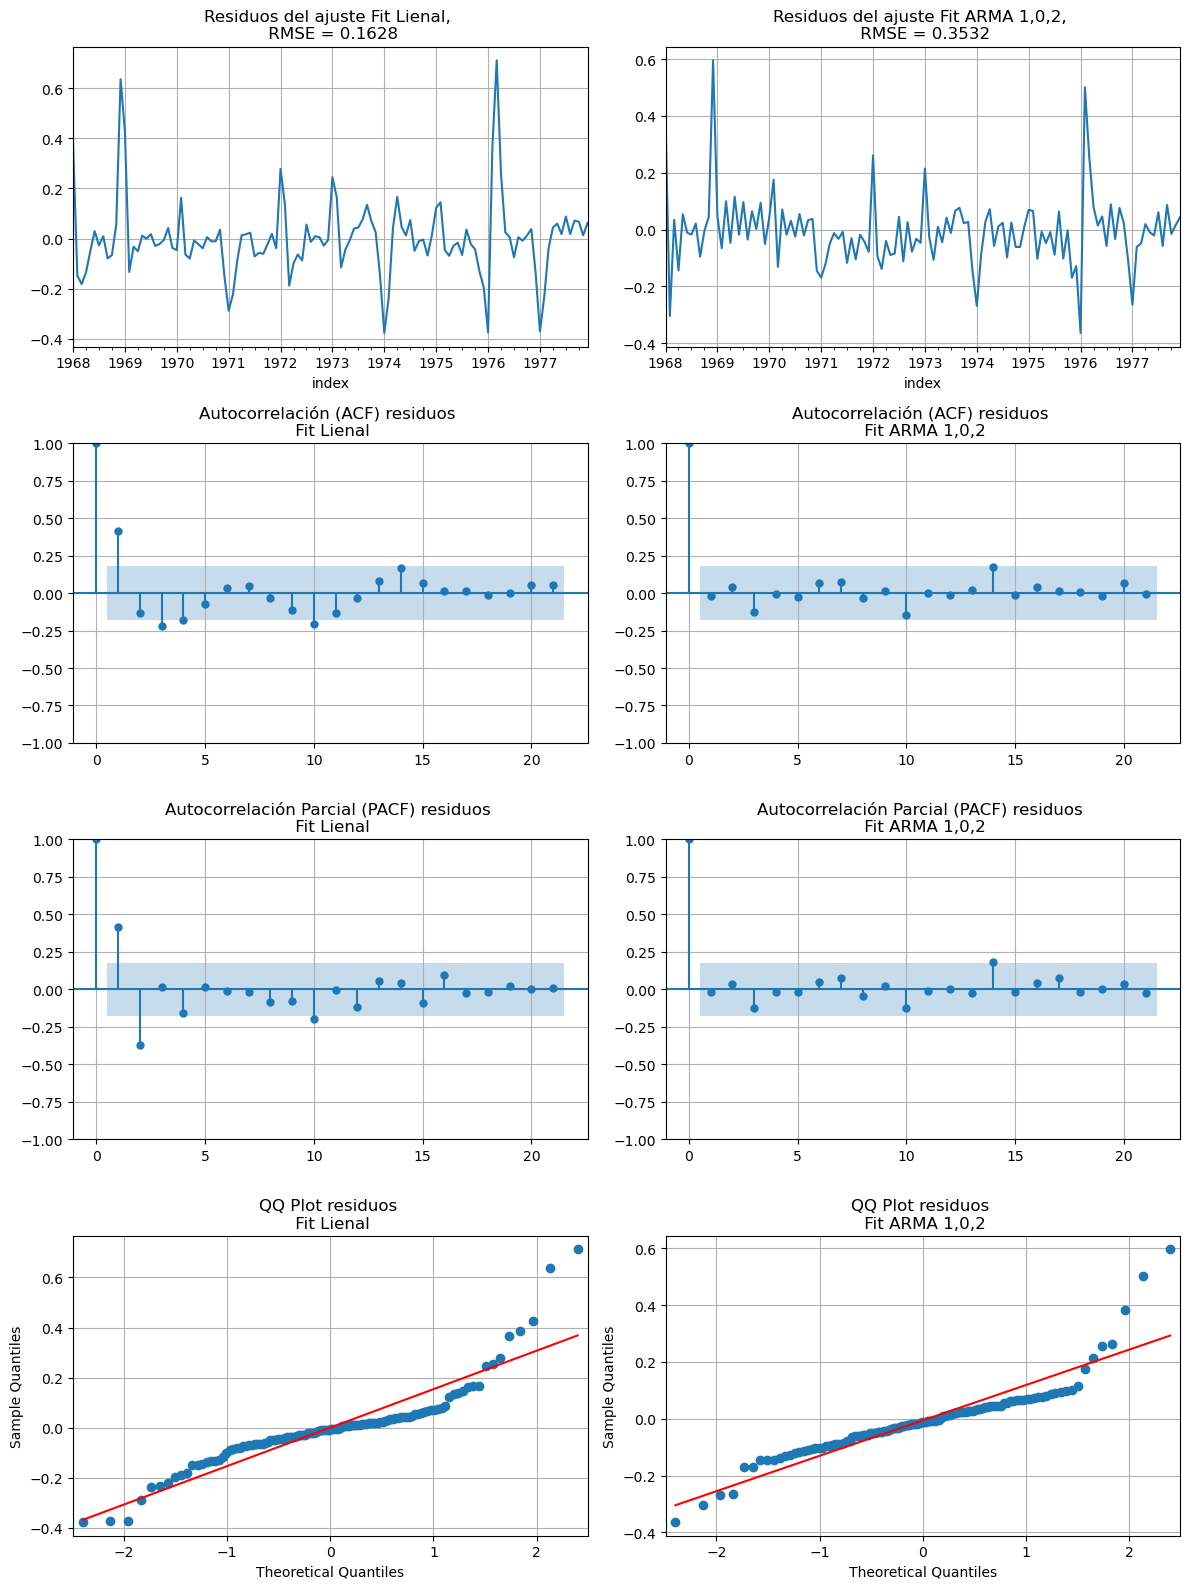

In [61]:
plot_fits([fit1,fit2],[mse1, mse2],["Fit Lienal","Fit ARMA 1,0,2"] )

### Item 5

In [78]:
# 1. Definimos time para el test
time_test = pd.Series(np.arange(len(x_train), len(x_train) + len(x_test)), index=x_test.index)
# 2. Creamos x_test_df (ahora x_test.index.month funcionará correctamente)
x_test_df = pd.DataFrame(index=x_test.index)
x_test_df["time"] = time_test
x_test_df["month"] = x_test.index.month
# 3. Predecimos la componente lineal en el test
pred_lineal_test = fit1.predict(x_test_df)

In [ ]:
# 4. Calculamos residuos de test
y_test = x_test["value"] if isinstance(x_test, pd.DataFrame) else x_test
residuos_test = y_test - pred_lineal_test
# 5. Hacemos el append (no necesitas configurar .freq manualmente en un PeriodIndex)
fit2_extended = fit2.append(residuos_test)
# 6. Obtenemos predicciones
predicciones2 = fit2_extended.get_prediction(start=x.index[0], end=x.index[-1])
xhat2 = predicciones2.predicted_mean
confint2 = predicciones2.conf_int(alpha=0.05) #alpha es la confianza del intervalo

### Item 6

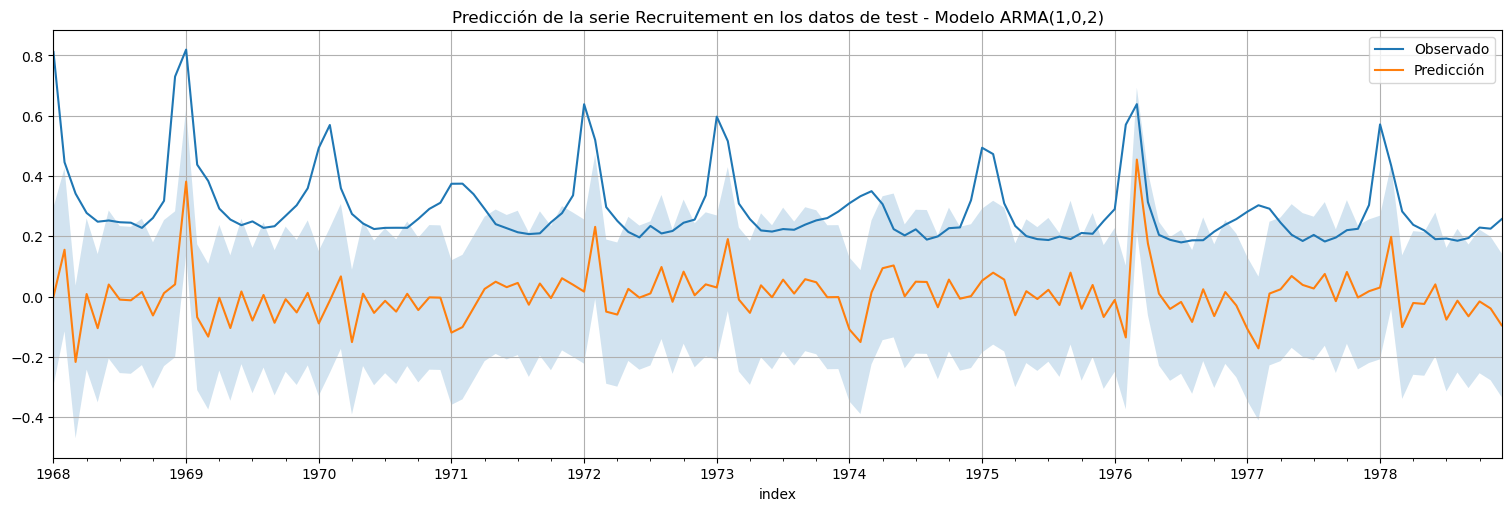

In [85]:
flu.plot()
xhat2.plot()
plt.legend(["Observado","Predicción"])
plt.fill_between(xhat2.index, confint2.iloc[:, 0], confint2.iloc[:, 1], alpha=0.2)
plt.title(f"Predicción de la serie Recruitement en los datos de test - Modelo ARMA(1,0,2)");

## Ejercicio 2

Se considera la serie mensual de cobertura nubosa en el Lago Shatsa, California, incluida en la biblioteca `astsa`, en el objeto `climhyd`.

1. Realice un análisis por frecuencias de la serie.
2. Ajuste un modelo de tendencia lineal más frecuencias que considere adecuado. Elimine las variables no significativas.
3. Realice un análisis de los residuos obtenidos del ajuste (no seguir ajustando).
4. En el mismo objeto `climhyd`, se tiene la serie mensual de aportes o `Inflow` de agua al lago.
     1. Realice la transformación $\log$ a la serie inflow.
     2. Realice un estudio de la correlación cruzada entre ambas series.
     3. Proponga un modelo para predecir Inflow a partir del lag más significativo de cloud cover.

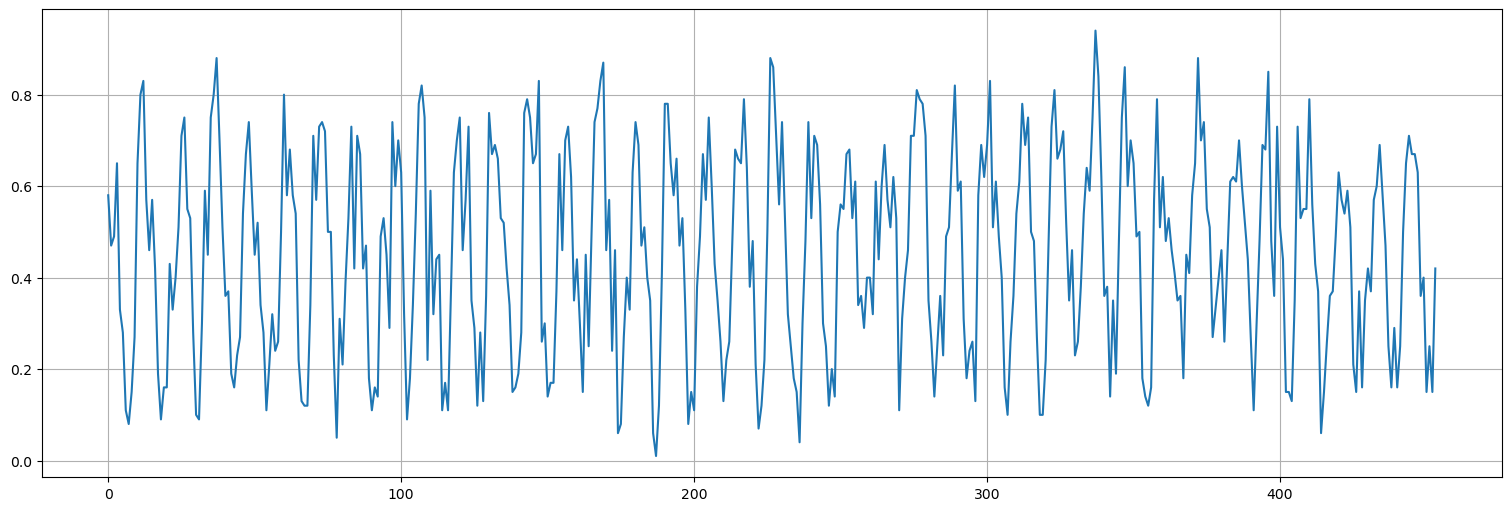

In [156]:
cloud = astsa.climhyd.CldCvr
cloud.plot();

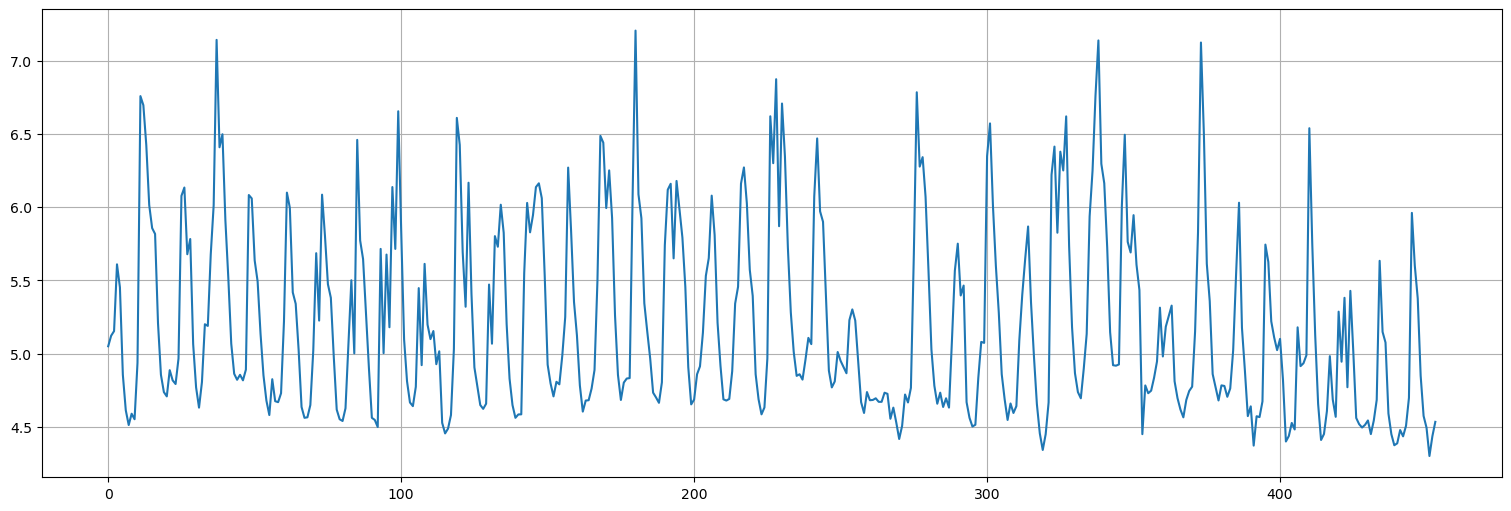

In [161]:
inflow = astsa.climhyd.Inflow
log_inflow = np.log(inflow)
log_inflow.plot();

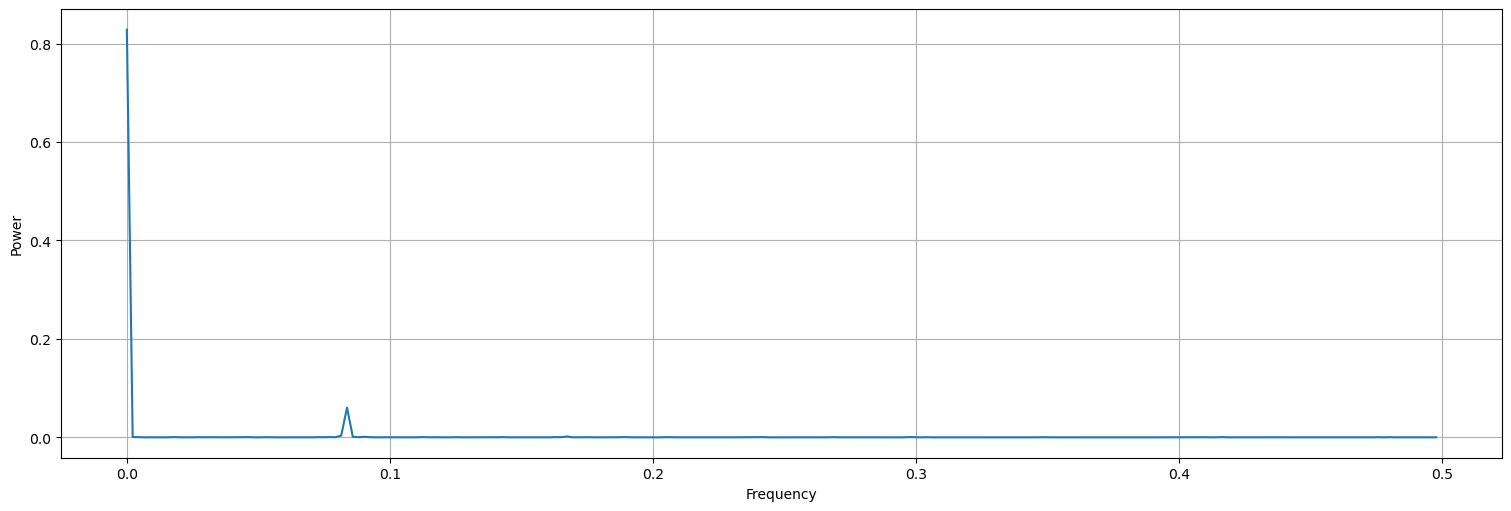

In [148]:
periodogram(cloud)

In [149]:
def spectrum(x,sampling_frequency=1, nfreq=10):

    """Función que calcula las componentes más relevantes del periodograma.
    
    Parameters
    ----------
        x : array_like, data.
        sampling_frequency: frecuencia de muestreo de la serie, para graficar.
    """

    n = x.size
    nfreq = np.minimum(nfreq,round(n/2)) #corto nfreq si la serie es muy corta!
    P = 4/n**2 * np.abs(np.fft.fft(x))**2
    P = P[0:round(n/2)]
    f = np.arange(0,round(n/2))/n * sampling_frequency
    index = np.argsort(P)[::-1] #ordeno P decreciente
    return pd.DataFrame({"Frecuencia" : f[index[0:nfreq]],"Potencia" : P[index[0:nfreq]]})

In [150]:
climdf_df = spectrum(cloud)
print(climdf_df)

   Frecuencia  Potencia
0    0.000000  0.828100
1    0.083700  0.060420
2    0.081498  0.003592
3    0.167401  0.001675
4    0.090308  0.001010
5    0.085903  0.001005
6    0.002203  0.000639
7    0.112335  0.000614
8    0.189427  0.000594
9    0.077093  0.000552


In [93]:
1/0.083700

11.947431302270012

Lo que se puede ver, es que en 0.083 hay una fuerte componente de frecuencia. Lo que indica una frecuencia anual en el seasonal.

In [151]:
cloud.head()

0    0.58
1    0.47
2    0.49
3    0.65
4    0.33
Name: CldCvr, dtype: float64

In [157]:
cloud_log = np.log(cloud)

In [158]:
time = pd.Series(np.arange(len(cloud_log)),index=cloud_log.index)
clund_reg = pd.concat([time, cloud_log], axis=1)
clund_reg.columns = ["time","cov"]

In [174]:
f = 0.083700
fit_freq = ols(formula="cov ~ time + np.cos(2*np.pi*f*time) + np.sin(2*np.pi*f*time)", data=clund_reg).fit()
freq_mse=np.sqrt(fit_freq.mse_resid)
print(f"RMSE de los residuos: {fit_freq}")
fit_freq.summary()

RMSE de los residuos: <statsmodels.regression.linear_model.RegressionResultsWrapper object at 0x17d9095d0>


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cov   R-squared:                       0.572
Model:                            OLS   Adj. R-squared:                  0.569
Method:                 Least Squares   F-statistic:                     200.4
Date:                Sun, 12 Jul 2026   Prob (F-statistic):           1.59e-82
Time:                        22:01:21   Log-Likelihood:                -253.16
No. Observations:                 454   AIC:                             514.3
Df Residuals:                     450   BIC:                             530.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                       -1.0399      0.040    -26.139      0.000      -1.118      -0.962
time                             0.0004      0.000      2.586      0.010    9.43e-05       0.001
np.cos(2 * np.pi * f * time)     0.4774      0.028     16.945      0.000       0.422       0.533
np.sin(2 * np.pi * f * time)     0.4958      0.028     17.594      0.000       0.440       0.551
==============================================================================
Omnibus:                      138.088   Durbin-Watson:                   1.419
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              678.647
Skew:                          -1.237   Prob(JB):                    4.30e-148
Kurtosis:                       8.455   Cond. No.                         523.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

/var/folders/zc/xfn7bz2d1wj_vv2lvqvmndcr0000gp/T/ipykernel_12850/3390279225.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


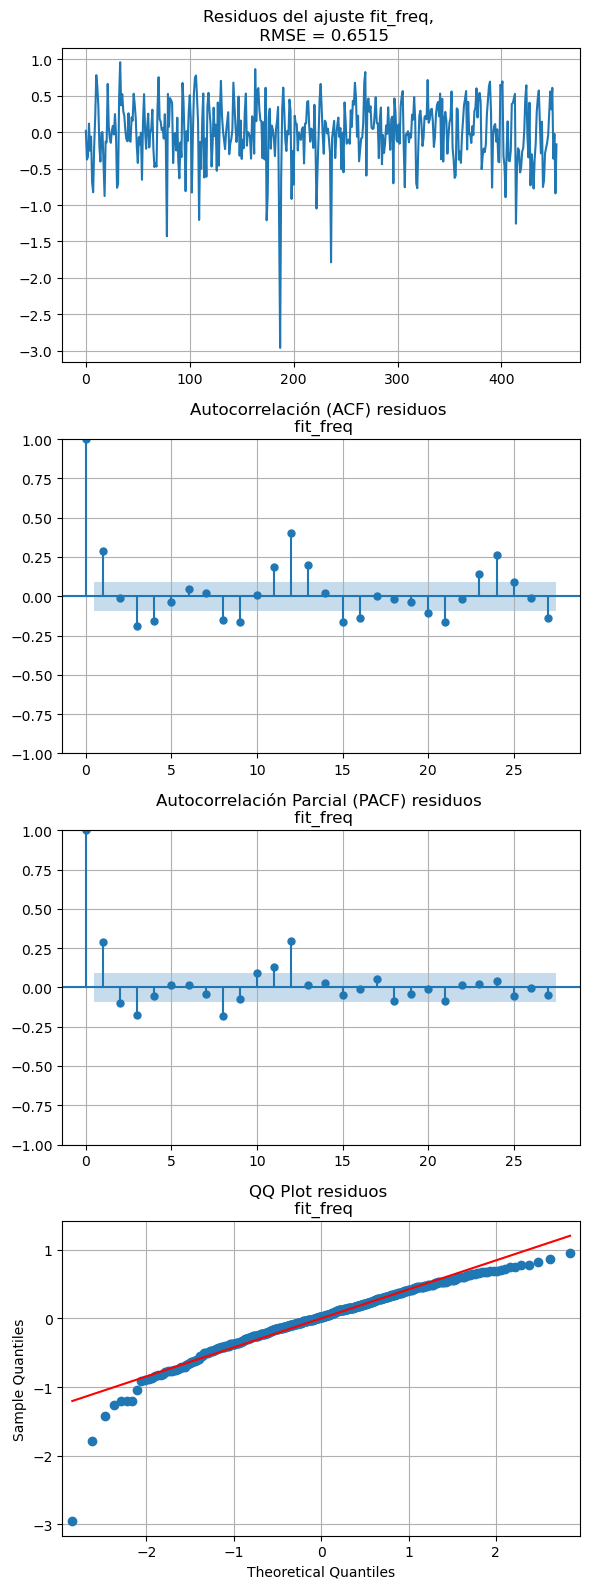

In [160]:
plot_fits([fit_freq],[freq_mse],["fit_freq"])

Lo que puede verse en los es que ya se asemeja mas a un ruido blanco. Igualmente parece en el ACF y PACF que se mantienen componentes de frecnuencia en cerca de 12 meses. 

Pero se los atribuiria mas a que falta ajustar una componente autorrgresiva y una componetne de media movil.

In [166]:
dcloud = cloud_log.diff().dropna()
dinflow = log_inflow.diff().dropna()

<Axes: xlabel='LAG', ylabel='CCF'>

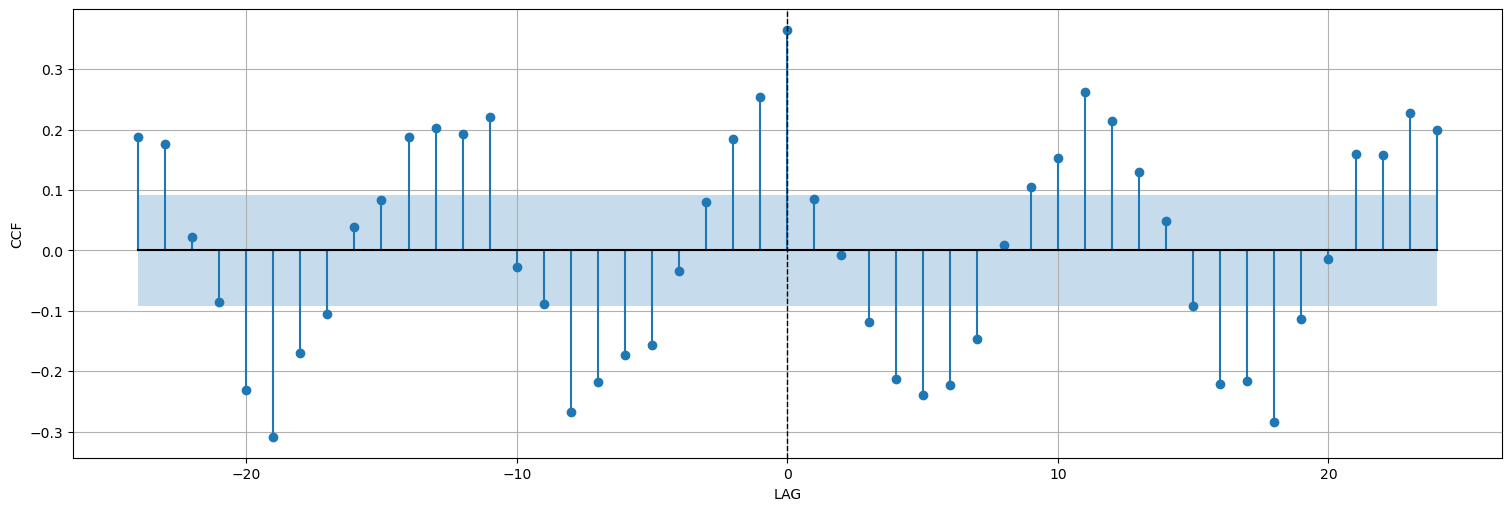

In [167]:
ccf(dcloud, dinflow, max_lag=24)

In [184]:
time = pd.Series(np.arange(len(cloud_log)),index=cloud_log.index)

clund_reg = pd.concat([time, cloud_log.shift(1),  cloud_log.shift(2),  log_inflow], axis=1)
clund_reg.columns = ["time","covlag1","covlag2", "infoflow"]

In [185]:
f = 0.083700
fit_cross = ols(formula="infoflow ~ covlag1 +covlag2 + time + np.cos(2*np.pi*f*time) + np.sin(2*np.pi*f*time) ", data=clund_reg).fit()
cross_mse=np.sqrt(fit_cross.mse_resid)
print(f"RMSE de los residuos: {cross_mse}")
fit_cross.summary()

RMSE de los residuos: 0.42991959903775606


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               infoflow   R-squared:                       0.547
Model:                            OLS   Adj. R-squared:                  0.542
Method:                 Least Squares   F-statistic:                     107.6
Date:                Sun, 12 Jul 2026   Prob (F-statistic):           2.51e-74
Time:                        22:50:14   Log-Likelihood:                -256.78
No. Observations:                 452   AIC:                             525.6
Df Residuals:                     446   BIC:                             550.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        5.7434      0.074     77.324      0.000       5.597       5.889
covlag1                          0.2414      0.050      4.837      0.000       0.143       0.339
covlag2                          0.1021      0.050      2.038      0.042       0.004       0.201
time                            -0.0009      0.000     -5.634      0.000      -0.001      -0.001
np.cos(2 * np.pi * f * time)     0.1807      0.032      5.649      0.000       0.118       0.244
np.sin(2 * np.pi * f * time)     0.3607      0.049      7.388      0.000       0.265       0.457
==============================================================================
Omnibus:                       34.023   Durbin-Watson:                   0.905
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               43.236
Skew:                           0.613   Prob(JB):                     4.09e-10
Kurtosis:                       3.891   Cond. No.                     1.18e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.18e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

/var/folders/zc/xfn7bz2d1wj_vv2lvqvmndcr0000gp/T/ipykernel_12850/3390279225.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


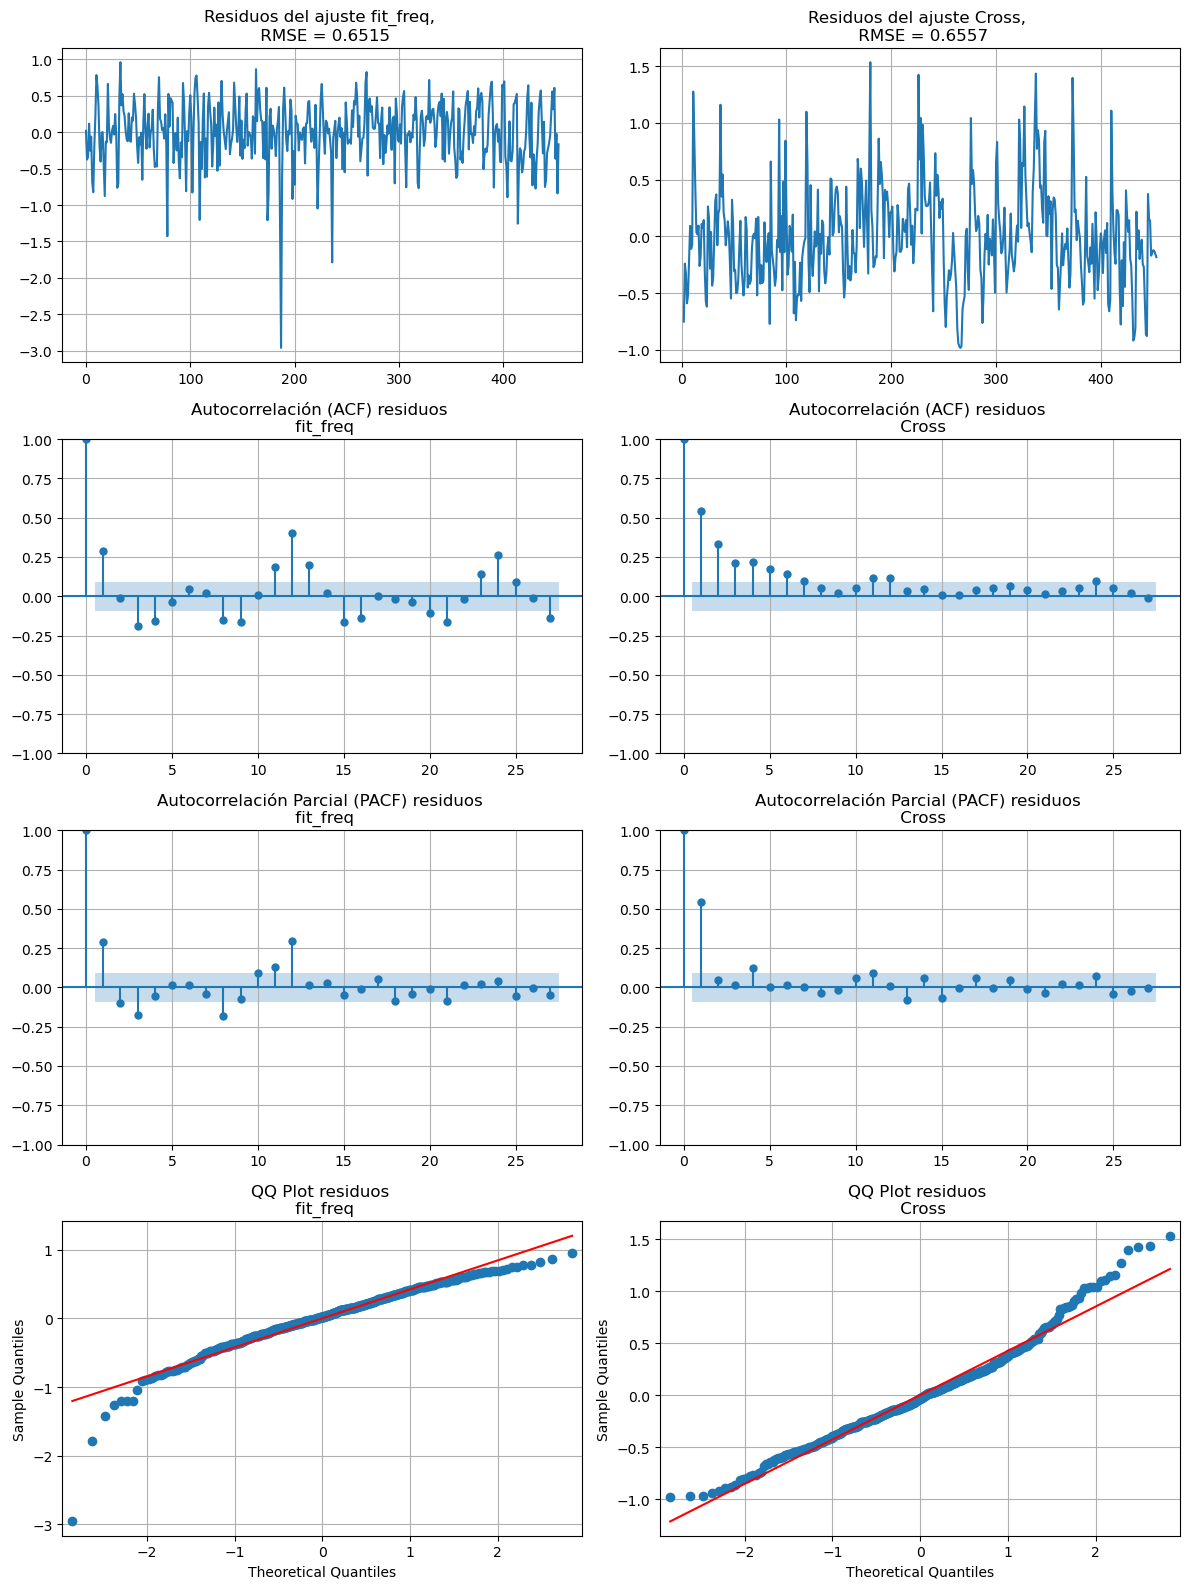

In [186]:
plot_fits([fit_freq,fit_cross],[freq_mse, cross_mse],["fit_freq", "Cross"])

## Ejercicio 3

Considere la serie de datos `casos` de incidencia de casos de Covid-19 en Uruguay. 

1. Aplique un modelo estructural de espacio de estados de tipo `UnobservedComponents` con componentes `level=True`, `stochastic_level=True` y `stochastic_seasonal=True` con frecuencia `seasonal=7`.
2. Graficar la tendencia central y la componente estacional obtenidas.

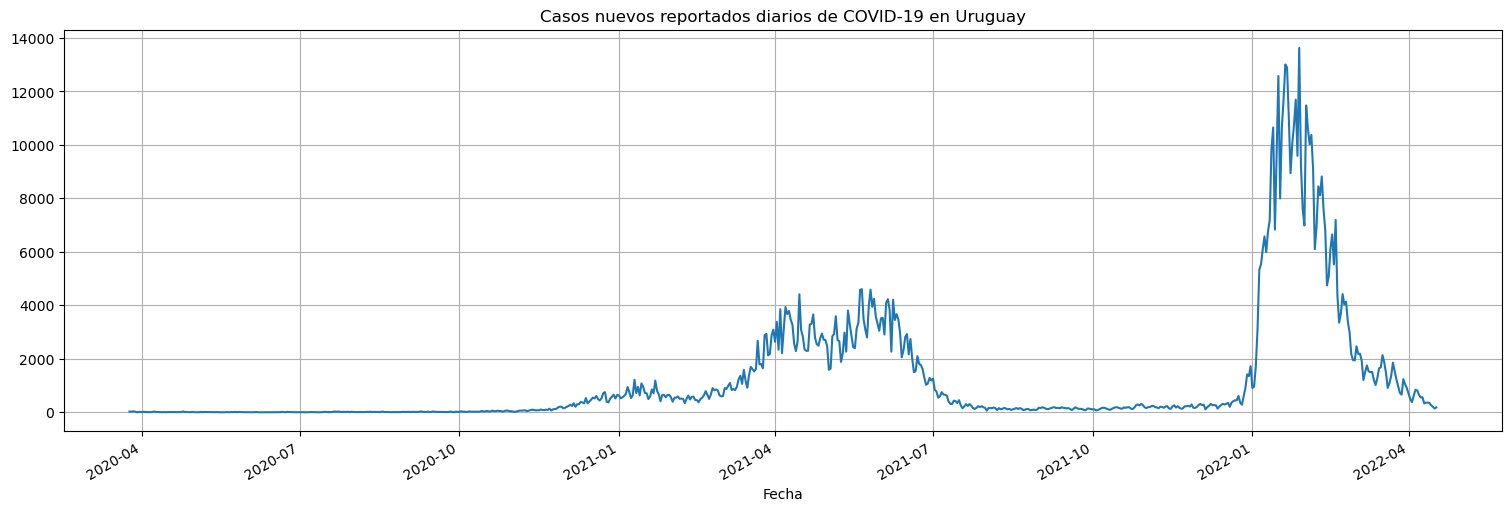

In [188]:
data = pd.read_csv("https://raw.githubusercontent.com/GUIAD-COVID/datos-y-visualizaciones-GUIAD/master/datos/estadisticasUY.csv", index_col=[0], parse_dates=[0], date_format="%d/%m/%Y")
casos = data["cantCasosNuevosAjustado"]
casos.plot(xlabel="Fecha", title="Casos nuevos reportados diarios de COVID-19 en Uruguay");

In [189]:
casos.head()

fecha
2020-03-25    28
2020-03-26    21
2020-03-27    36
2020-03-28    30
2020-03-29     6
Name: cantCasosNuevosAjustado, dtype: int64

In [210]:
model = UnobservedComponents(
    casos, 
    irregular=True, 
    level=True,  
    stochastic_level=True, 
    stochastic_seasonal=True, 
    seasonal=7
)
#Hago el fit, pero en realidad le fijamos todos los parámetros:
fit = model.fit()
fit.summary()

/Users/juancruz/miniconda3/envs/series/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/juancruz/miniconda3/envs/series/lib/python3.11/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Unobserved Components Results                            
====================================================================================
Dep. Variable:      cantCasosNuevosAjustado   No. Observations:                  753
Model:                          local level   Log Likelihood               -5745.479
                   + stochastic seasonal(7)   AIC                          11496.957
Date:                      Sun, 12 Jul 2026   BIC                          11510.801
Time:                              23:18:59   HQIC                         11502.293
Sample:                                   0                                         
                                      - 753                                         
Covariance Type:                        opg                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
sigma2.irregular  1.083e+05   3625.346     29.877      0.000    1.01e+05    1.15e+05
sigma2.level      7.866e+04   3386.623     23.227      0.000     7.2e+04    8.53e+04
sigma2.seasonal   1711.1932    279.320      6.126      0.000    1163.736    2258.650
===================================================================================
Ljung-Box (L1) (Q):                   1.72   Jarque-Bera (JB):             10941.79
Prob(Q):                              0.19   Prob(JB):                         0.00
Heteroskedasticity (H):            4420.16   Skew:                             0.53
Prob(H) (two-sided):                  0.00   Kurtosis:                        21.73
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

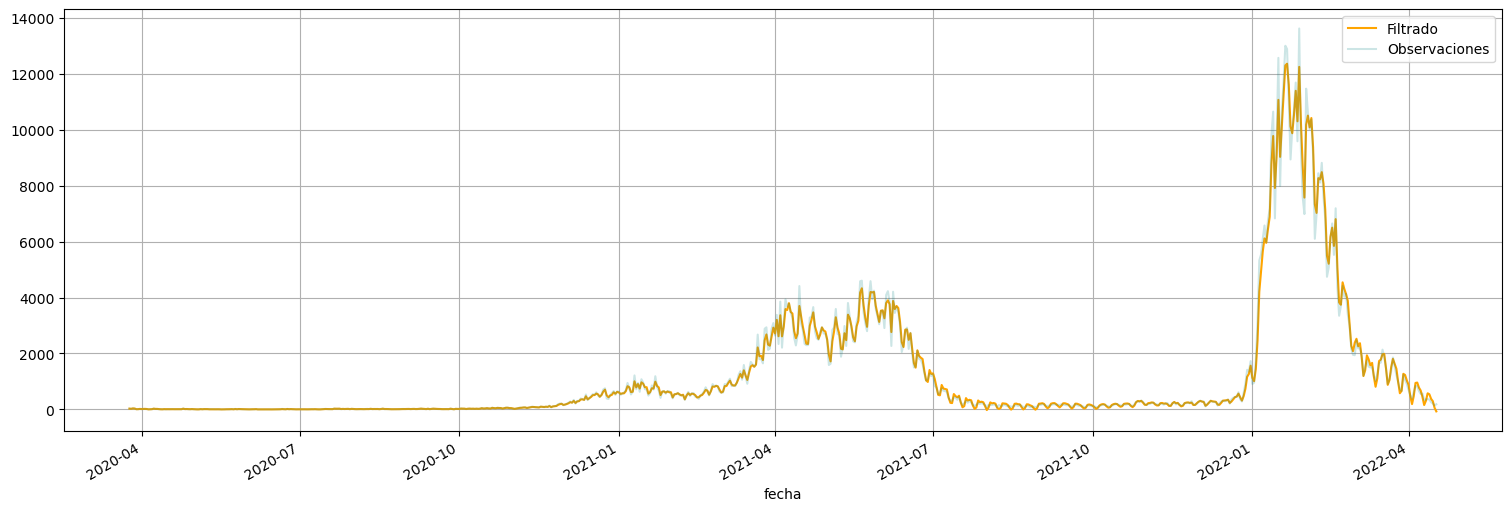

In [211]:
filtered = fit.get_prediction(information_set="filtered")
xhat = filtered.predicted_mean
xhat = pd.Series(xhat)
xhat.plot(color="orange", label="Filtrado")
casos.plot(alpha=0.2, color="teal", label="Observaciones")
plt.legend();

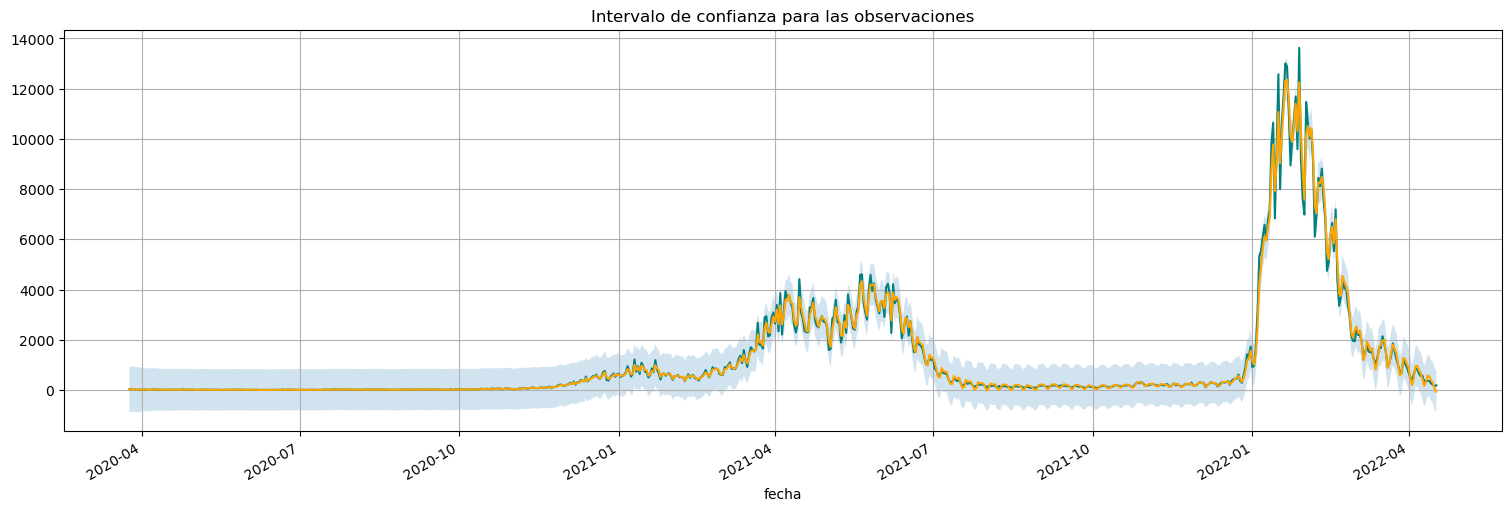

In [212]:
confint = filtered.conf_int(0.05)
casos.plot(color="teal")
xhat.plot(color="orange")
plt.fill_between(casos.index,confint["lower cantCasosNuevosAjustado"], confint["upper cantCasosNuevosAjustado"],alpha=0.2)
plt.title("Intervalo de confianza para las observaciones");

/Users/juancruz/miniconda3/envs/series/lib/python3.11/site-packages/statsmodels/tsa/statespace/mlemodel.py:2999: ValueWarning: No supported index is available. The `states` DataFrame uses a generated integer index
  warnings.warn('No supported index is available. The `states`'


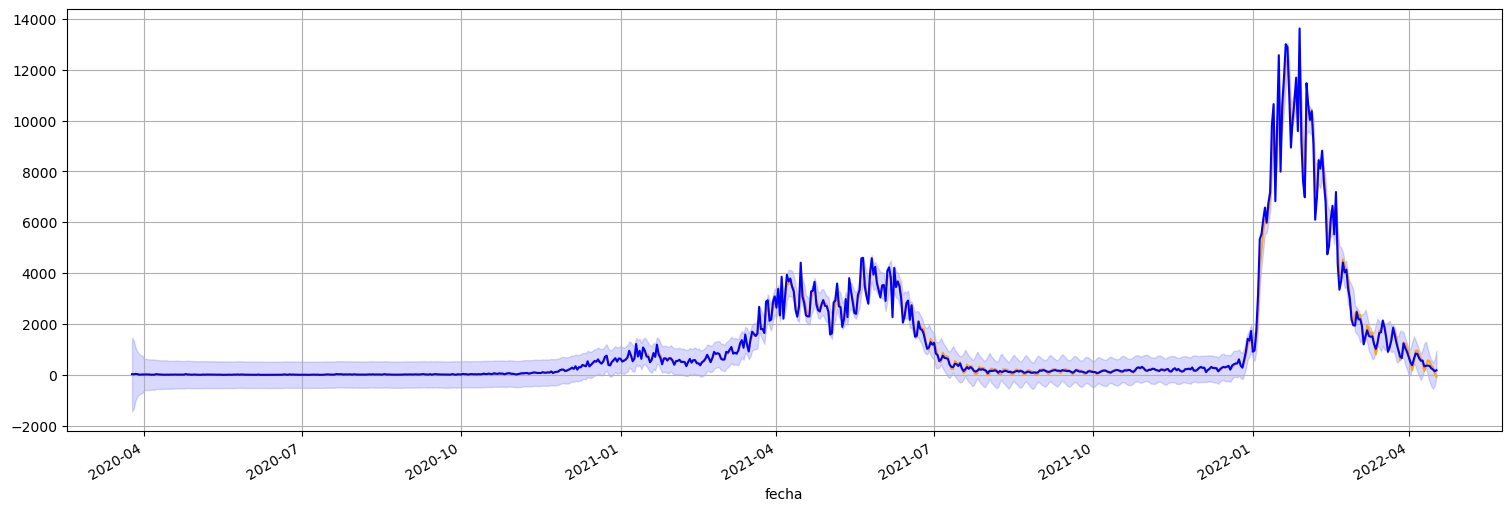

In [213]:
var_level = fit.states.filtered_cov.loc['level', 'level']
varxhat = pd.Series(var_level.values, index=casos.index)
xhat.plot(color="orange", label="Filtrado")
casos.plot(color="blue", label="Estado real (oculto)")
desv_est = np.sqrt(varxhat)
plt.fill_between(
    casos.index, 
    fit.level.filtered - 2 * desv_est, 
    fit.level.filtered + 2 * desv_est, 
    color="blue", 
    alpha=0.15, 
    label="Confianza del Estado Real"
)

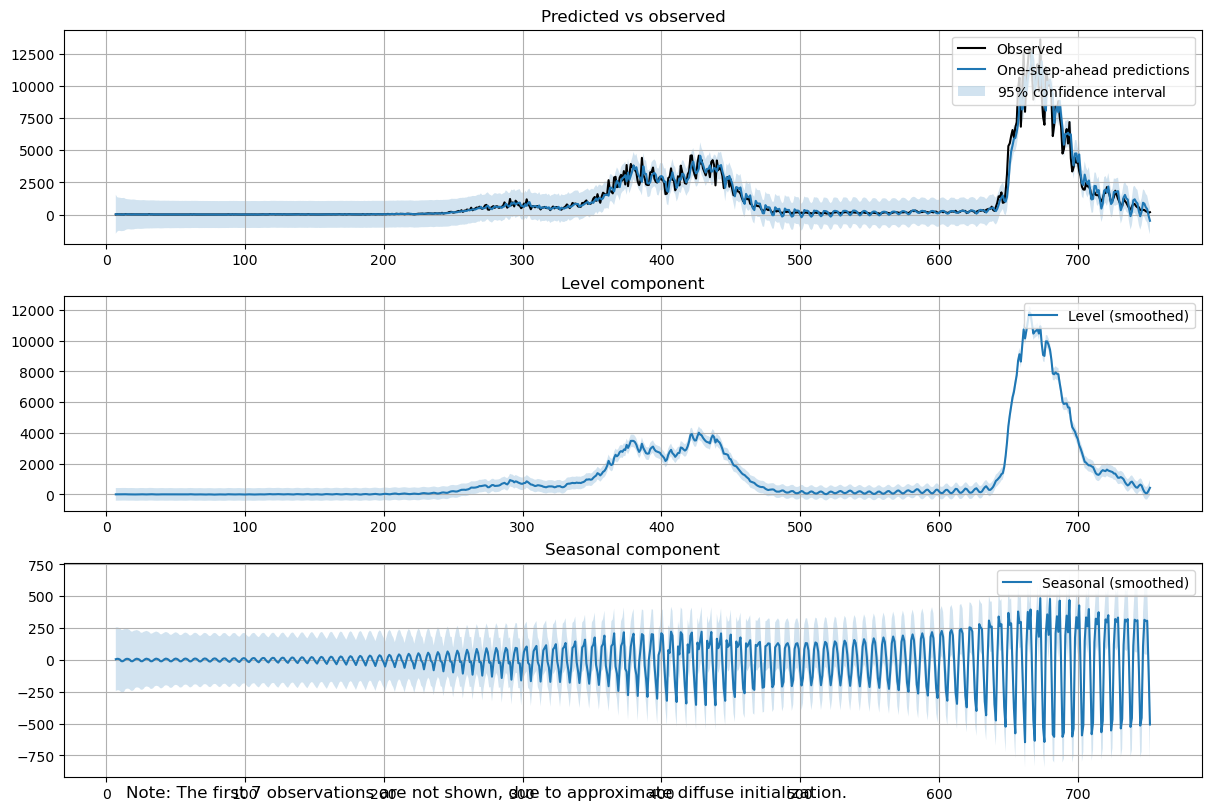

In [218]:
fig = fit.plot_components( figsize=(12, 8))